# Problem statement 1-->
A certain food-based company conducted a survey with the help of a fitness company to find the relationship between a person’s weight gain and the number of calories they consumed in order to come up with diet plans for these individuals. Build a Simple Linear Regression model with calories consumed as the target variable. Apply necessary transformations and record the RMSE and correlation coefficient values for different models. 


# Business Objectives-->
The goal of this analysis is to develop a predictive model that estimates the number of calories consumed based on various independent variables such as body measurements. This model can be useful for: 
Health & Fitness Tracking, Dietary Recommendations,Medical Use Cases, fitness aps,etc.

# Constraints:-->
Data Quality, 
Assumptions of Linear Regression:
Linearity assumption between features and target variable.
Homoscedasticity (constant variance of errors).
Normality of residuals.
No multicollinearity among independent variables

In [18]:
#load required libraries
import pandas as pd
import numpy as np
import seaborn as sns

In [19]:
#load dataset
df = pd.read_csv("calories_consumed.csv")

In [20]:
#EDA (Exploratory Data Analysis)
#print 1st 5 rows for datset understanding
df.head(5)

,Weight gained (grams),Calories Consumed
0,108,1500
1,200,2300
2,900,3400
3,200,2200
4,300,2500


In [21]:
#print shape of datset
df.shape

(14, 2)

In [22]:
# Rename columns for ease of use 
df.columns = ["Weight_Gained", "Calories_Consumed"]

In [23]:
df.columns

Index(['Weight_Gained', 'Calories_Consumed'], dtype='object')

In [24]:
# describe the dataset
df.describe()

,Weight_Gained,Calories_Consumed
count,14.000000,14.000000
mean,357.714286,2340.714286
std,333.692495,752.109488
min,62.000000,1400.000000
25%,114.500000,1727.500000
50%,200.000000,2250.000000
75%,537.500000,2775.000000
max,1100.000000,3900.000000


Average Weight_Gained is 357.71(mean) and min is 62.00 and max is 1100

Average AT is 2340.71(mean) and min is 62.00 and max is 3900.00

C:\Users\Sai\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Calories_Consumed', ylabel='Density'>

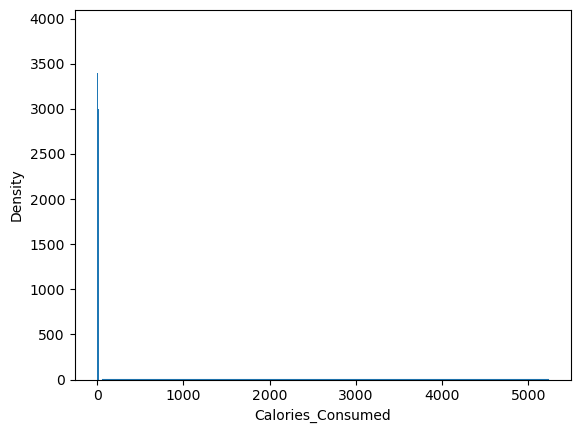

In [28]:
import matplotlib.pyplot as plt
plt.bar(height=df.Calories_Consumed, x=np.arange(1,15,1))
sns.distplot(df.Calories_Consumed)

Observation: The dataset lacks variability, which means "Calories Consumed" does not significantly change across different data points.

{'whiskers': [<matplotlib.lines.Line2D at 0x295ad287a00>,
 'caps': [<matplotlib.lines.Line2D at 0x295ad287fa0>,
 'boxes': [<matplotlib.lines.Line2D at 0x295ac92a610>],
 'medians': [<matplotlib.lines.Line2D at 0x295ad298580>],
 'fliers': [<matplotlib.lines.Line2D at 0x295ad298850>],
 'means': []}

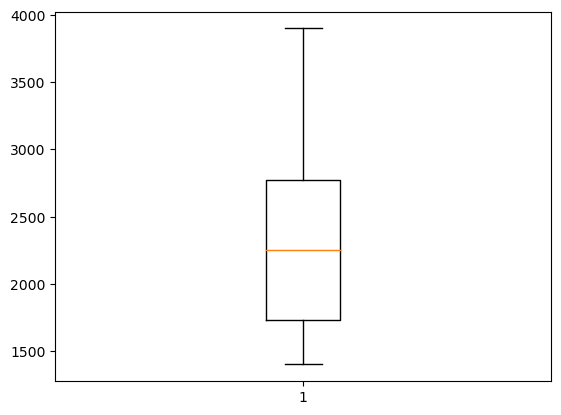

In [29]:
plt.boxplot(df.Calories_Consumed)

No outliers

C:\Users\Sai\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Weight_Gained', ylabel='Density'>

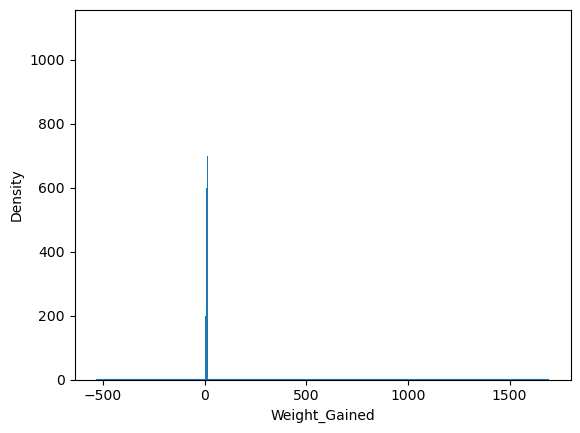

In [31]:
plt.bar(height=df.Weight_Gained,x=np.arange(1,15,1))
sns.distplot(df.Weight_Gained)

Data is normal

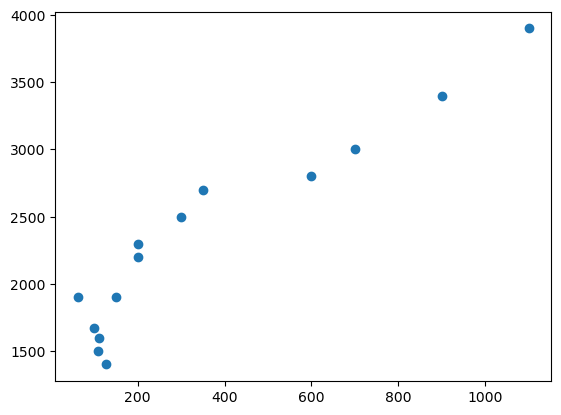

In [32]:
#Bivariant analysis
plt.scatter(x=df.Weight_Gained, y=df.Calories_Consumed)

The data is linearly scattered, with a positive direction and a moderate to strong strength.

In [34]:
#now let us check the correlation coeficient
np.corrcoef(df.Weight_Gained,df.Calories_Consumed)

array([[1.        , 0.94699101],
       [0.94699101, 1.        ]])

the correlation coeficient is 0.9469 > 0.85 hence the correlation is very strong

In [37]:
#let us check the direction of corrletion
cov_output=np.cov(df.Weight_Gained,df.Calories_Consumed)[0,1]
cov_output

237669.4505494506

237669.45, it is positive means correlation will be positive

In [39]:
#let us apply to various models and check the feasibility
import statsmodels.formula.api as smf

In [43]:
#first simple linear model
model=smf.ols('Calories_Consumed~Weight_Gained',data=df).fit()
#Y is Calories_Consumed and X is Weight_Gained
model.summary()

C:\Users\Sai\anaconda3\lib\site-packages\scipy\stats\_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=14
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      Calories_Consumed   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.888
Method:                 Least Squares   F-statistic:                     104.3
Date:                Sat, 01 Mar 2025   Prob (F-statistic):           2.86e-07
Time:                        14:20:13   Log-Likelihood:                -96.170
No. Observations:                  14   AIC:                             196.3
Df Residuals:                      12   BIC:                             197.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      1577.2007    100.541     15.687      0.000    1358.141    1796.260
Weight_Gained     2.1344      0.209     10.211      0.000       1.679       2.590
==============================================================================
Omnibus:                        0.254   Durbin-Watson:                   2.308
Prob(Omnibus):                  0.881   Jarque-Bera (JB):                0.425
Skew:                          -0.098   Prob(JB):                        0.808
Kurtosis:                       2.169   Cond. No.                         719.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

R-squared = 0.897. This indicates that approximately 89.7% of the variability in Calories_Consumed is explained by Weight_Gained

p = 2.86e-07 This is much smaller than the typical significance level of 0.05.

beta-0(intercept) = 1577.2007 This is the estimated Calories_Consumed when Weight_Gained is zero

beta-1(slpoe) = 2.1344 This means that for every one unit increase in Weight_Gained, Calories_Consumed is estimated to increase by 2.1344 units

In [45]:
pred1=model.predict(pd.DataFrame(df.Weight_Gained))
pred1

0     1807.718381
1     2004.085294
2     3498.181364
3     2004.085294
4     2217.527589
5     1811.987227
6     1850.406841
7     1709.534925
8     2857.854477
9     3925.065955
10    1790.642998
11    1897.364146
12    2324.248737
13    3071.296772
dtype: float64

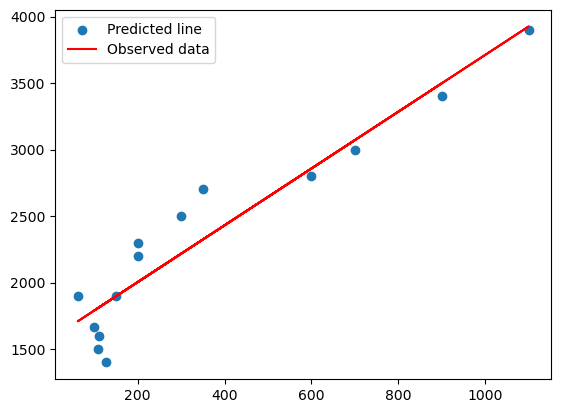

In [46]:
#Regression line
plt.scatter(df.Weight_Gained,df.Calories_Consumed)
plt.plot(df.Weight_Gained,pred1,'r')
plt.legend(['Predicted line','Observed data'])
plt.show()

In [48]:
##error calculation
res1=df.Calories_Consumed-pred1
np.mean(res1)
res_sqr1=res1*res1
mse1=np.mean(res_sqr1)
rmse1=np.sqrt(mse1)
rmse1
#232.83

232.8335007096088

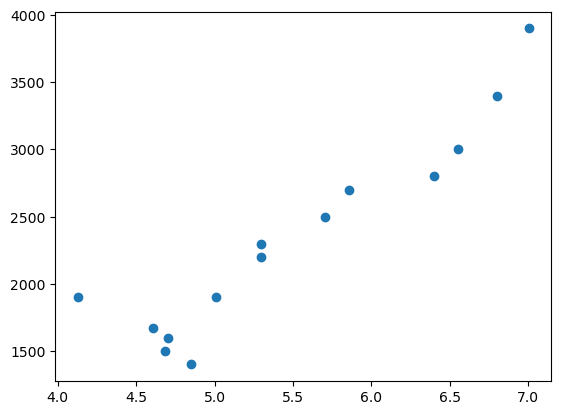

In [49]:
#let us try another model
#x=log(Weight_Gained)
plt.scatter(x=np.log(df.Weight_Gained), y=df.Calories_Consumed)

The data is linearly scattered, with a positive direction and a moderate to strong strength.

In [59]:
#Now let us check the correlation coeficient
np.corrcoef(np.log(df.Weight_Gained),df.Calories_Consumed)
#The corrlation coeficient is 0.9368>0.85 hence the correlation
#r=0.9368

array([[1.        , 0.93680369],
       [0.93680369, 1.        ]])

In [52]:
model2=smf.ols('Calories_Consumed~np.log(Weight_Gained)',data=df).fit()
#Y is Calories_Consumed and x=log(Weight_Gained)
model2.summary()

C:\Users\Sai\anaconda3\lib\site-packages\scipy\stats\_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=14
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      Calories_Consumed   R-squared:                       0.878
Model:                            OLS   Adj. R-squared:                  0.867
Method:                 Least Squares   F-statistic:                     86.04
Date:                Sat, 01 Mar 2025   Prob (F-statistic):           8.02e-07
Time:                        14:31:35   Log-Likelihood:                -97.363
No. Observations:                  14   AIC:                             198.7
Df Residuals:                      12   BIC:                             200.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept             -1911.1244    464.188     -4.117      0.001   -2922.503    -899.746
np.log(Weight_Gained)   774.1735     83.462      9.276      0.000     592.326     956.021
==============================================================================
Omnibus:                        4.026   Durbin-Watson:                   3.009
Prob(Omnibus):                  0.134   Jarque-Bera (JB):                1.659
Skew:                           0.772   Prob(JB):                        0.436
Kurtosis:                       3.679   Cond. No.                         36.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

R-squared = 0.878.This means that approximately 87.8% of the variability in Calories_Consumed is explained by the natural logarithm of Weight_Gained

p = 8.02e-07. This is much smaller than 0.05, so you're correct that the model is acceptable (we reject the null hypothesis of no relationship).

beta-0 = -1911.1244. This is the estimated Calories_Consumed when np.log(Weight_Gained) is zero.

beta-1 = 774.1735 This means that for a one unit increase in the natural logarithm of Weight_Gained, Calories_Consumed is estimated to increase by 774.1735 units.

In [53]:
pred2=model2.predict(pd.DataFrame(df.Weight_Gained))
pred2

0     1713.657759
1     2190.692769
2     3355.109707
3     2190.692769
4     2504.593132
5     1727.863176
6     1845.189099
7     1283.993883
8     3041.209345
9     3510.463652
10    1654.076556
11    1967.976918
12    2623.932511
13    3160.548724
dtype: float64

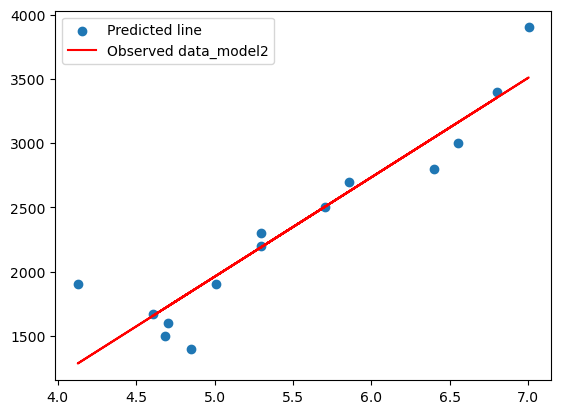

In [54]:
#Regression line
plt.scatter(np.log(df.Weight_Gained),df.Calories_Consumed)
plt.plot(np.log(df.Weight_Gained),pred2,'r')
plt.legend(['Predicted line','Observed data_model2'])
plt.show()

In [56]:
##error calculation
res2=df.Calories_Consumed-pred2
np.mean(res2)
res_sqr2=res2*res2
mse2=np.mean(res_sqr2)
rmse2=np.sqrt(mse2)
rmse2
#253.55
#There is no significant change as r=0.9368, RSqure=0.878 and RMSE=.


253.5580403936626

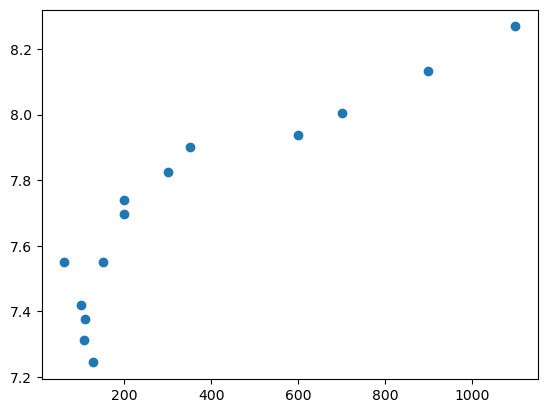

In [58]:
#Hence let us try another model(Model 3)
plt.scatter(x=(df.Weight_Gained),y=np.log(df.Calories_Consumed))

The data is linearly scattered, with a positive direction and a moderate to strong strength.

In [60]:
#Now lwt us check the correlation coeficient
np.corrcoef(df.Weight_Gained,np.log(df.Calories_Consumed))

array([[1.        , 0.89872528],
       [0.89872528, 1.        ]])

r=0.89

In [61]:
model3=smf.ols('np.log(Calories_Consumed)~Weight_Gained',data=df).fit()
#Y is log(Calories_Consumed) and X=Weight_Gained
model3.summary()

C:\Users\Sai\anaconda3\lib\site-packages\scipy\stats\_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=14
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                OLS Regression Results                               
=====================================================================================
Dep. Variable:     np.log(Calories_Consumed)   R-squared:                       0.808
Model:                                   OLS   Adj. R-squared:                  0.792
Method:                        Least Squares   F-statistic:                     50.40
Date:                       Sat, 01 Mar 2025   Prob (F-statistic):           1.25e-05
Time:                               14:54:08   Log-Likelihood:                 8.3130
No. Observations:                         14   AIC:                            -12.63
Df Residuals:                             12   BIC:                            -11.35
Df Model:                                  1                                         
Covariance Type:                   nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         7.4068      0.058    128.367      0.000       7.281       7.533
Weight_Gained     0.0009      0.000      7.100      0.000       0.001       0.001
==============================================================================
Omnibus:                        0.488   Durbin-Watson:                   2.068
Prob(Omnibus):                  0.783   Jarque-Bera (JB):                0.559
Skew:                          -0.317   Prob(JB):                        0.756
Kurtosis:                       2.254   Cond. No.                         719.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#R-squared=0.808,  
#p=0.783,  

In [63]:
pred3_at=model3.predict(pd.DataFrame(df.Weight_Gained))
pred3_at

0     7.498820
1     7.577174
2     8.173348
3     7.577174
4     7.662342
5     7.500523
6     7.515853
7     7.459642
8     7.917845
9     8.343684
10    7.492006
11    7.534590
12    7.704926
13    8.003013
dtype: float64

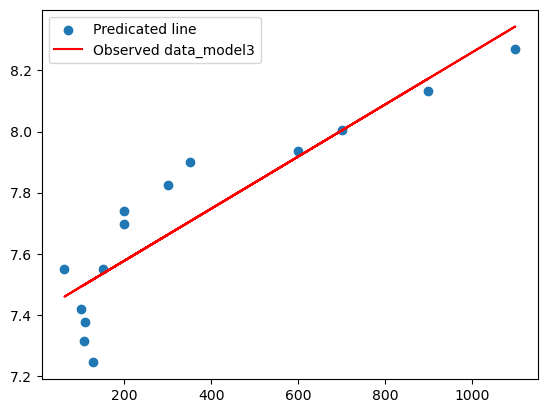

In [64]:
#Regression line
plt.scatter(df.Weight_Gained,np.log(df.Calories_Consumed))
plt.plot(df.Weight_Gained,pred3_at,'r')
plt.legend(['Predicated line','Observed data_model3'])
plt.show()

In [65]:
#error calculation
res3=df.Calories_Consumed-pred3_at
res_sqr3=res3*res3
mse3=np.mean(res_sqr3)
rmse3=np.sqrt(mse3)
rmse3

2442.9060461363415

In [70]:
#hence let us try another model
model4 = smf.ols('np.log(Calories_Consumed)~Weight_Gained+I(Weight_Gained*Weight_Gained)', data=df).fit()
model4.summary()

C:\Users\Sai\anaconda3\lib\site-packages\scipy\stats\_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=14
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                OLS Regression Results                               
=====================================================================================
Dep. Variable:     np.log(Calories_Consumed)   R-squared:                       0.852
Model:                                   OLS   Adj. R-squared:                  0.825
Method:                        Least Squares   F-statistic:                     31.55
Date:                       Sat, 01 Mar 2025   Prob (F-statistic):           2.78e-05
Time:                               15:03:01   Log-Likelihood:                 10.125
No. Observations:                         14   AIC:                            -14.25
Df Residuals:                             11   BIC:                            -12.33
Df Model:                                  2                                         
Covariance Type:                   nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                            7.2892      0.084     86.724      0.000       7.104       7.474
Weight_Gained                        0.0017      0.000      3.560      0.004       0.001       0.003
I(Weight_Gained * Weight_Gained) -7.689e-07   4.27e-07     -1.803      0.099   -1.71e-06     1.7e-07
==============================================================================
Omnibus:                        0.744   Durbin-Watson:                   2.647
Prob(Omnibus):                  0.689   Jarque-Bera (JB):                0.721
Skew:                          -0.394   Prob(JB):                        0.697
Kurtosis:                       2.217   Cond. No.                     1.01e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.01e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [73]:
pred4 = model4.predict(pd.DataFrame(df.Weight_Gained))
pred4_at = np.exp(pred4)
pred4_at

0     1739.606122
1     1986.232241
2     3556.374964
3     1986.232241
4     2260.501362
5     1744.868700
6     1792.457905
7     1620.099409
8     3038.496984
9     3657.476403
10    1718.608337
11    1851.135743
12    2397.660886
13    3251.772007
dtype: float64

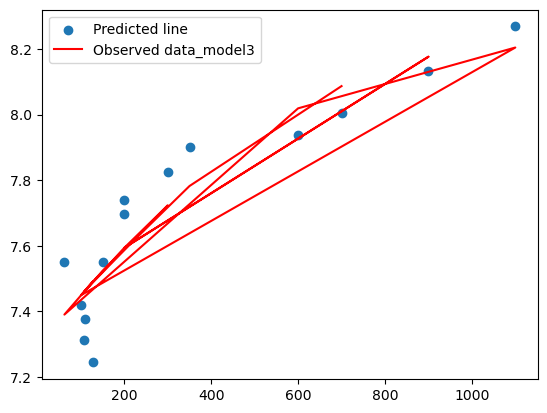

In [75]:
# Regression line
plt.scatter(df.Weight_Gained, np.log(df.Calories_Consumed))
plt.plot(df.Weight_Gained, pred4, 'r')
plt.legend(['Predicted line', 'Observed data_model3'])
plt.show()

In [76]:
# Error calculation
res4 = df.Calories_Consumed - pred4_at
res_sqr4 = res4 * res4
mse4 = np.mean(res_sqr4)
rmse4 = np.sqrt(mse4)
rmse4

240.82777570407256

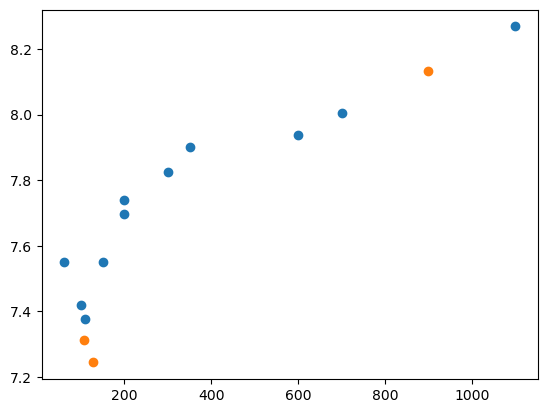

In [79]:
from sklearn.model_selection import train_test_split
# Train-test split
train, test = train_test_split(df, test_size=0.2)
plt.scatter(train.Weight_Gained, np.log(train.Calories_Consumed))
plt.scatter(test.Weight_Gained, np.log(test.Calories_Consumed))

In [80]:
# Final model
final_model = smf.ols('np.log(Calories_Consumed)~Weight_Gained+I(Weight_Gained*Weight_Gained)', data=df).fit()
final_model.summary()

C:\Users\Sai\anaconda3\lib\site-packages\scipy\stats\_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=14
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                OLS Regression Results                               
=====================================================================================
Dep. Variable:     np.log(Calories_Consumed)   R-squared:                       0.852
Model:                                   OLS   Adj. R-squared:                  0.825
Method:                        Least Squares   F-statistic:                     31.55
Date:                       Sat, 01 Mar 2025   Prob (F-statistic):           2.78e-05
Time:                               15:09:27   Log-Likelihood:                 10.125
No. Observations:                         14   AIC:                            -14.25
Df Residuals:                             11   BIC:                            -12.33
Df Model:                                  2                                         
Covariance Type:                   nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                            7.2892      0.084     86.724      0.000       7.104       7.474
Weight_Gained                        0.0017      0.000      3.560      0.004       0.001       0.003
I(Weight_Gained * Weight_Gained) -7.689e-07   4.27e-07     -1.803      0.099   -1.71e-06     1.7e-07
==============================================================================
Omnibus:                        0.744   Durbin-Watson:                   2.647
Prob(Omnibus):                  0.689   Jarque-Bera (JB):                0.721
Skew:                          -0.394   Prob(JB):                        0.697
Kurtosis:                       2.217   Cond. No.                     1.01e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.01e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [82]:
test_pred = final_model.predict(pd.DataFrame(test))
test_pred_at = np.exp(test_pred)
train_pred = final_model.predict(pd.DataFrame(train))
train_pred_at = np.exp(train_pred)

In [83]:
# Evaluation on test data
test_res = test.Calories_Consumed - test_pred_at
test_sqr = test_res * test_res
test_mse = np.mean(test_sqr)
test_rmse = np.sqrt(test_mse)
test_rmse

280.4088861330383

In [84]:
# Evaluation on train data
train_res = train.Calories_Consumed - train_pred_at
train_sqr = train_res * train_res
train_mse = np.mean(train_sqr)
train_rmse = np.sqrt(train_mse)
train_rmse

228.8478683716804

Observations:

Higher Test RMSE than Train RMSE

The test RMSE (280.41) is greater than the train RMSE (228.85), indicating that the model performs better on the training data but has higher error on unseen test data.
This suggests potential overfitting, meaning the model might be capturing noise from the training data rather than generalizing well.

Scope for Improvement

Since the RMSE values are relatively high, the model might not be accurately predicting Calories_Consumed based on Weight_Gained.